# 1. Loading and splitting dataset

In [1]:
import pandas as pd
import requests
import zipfile
import io

url = "https://archive.ics.uci.edu/static/public/294/combined+cycle+power+plant.zip"
response = requests.get(url)

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    z.extractall("/tmp")

df = pd.read_excel("/tmp/CCPP/Folds5x2_pp.xlsx")

display(df.head())

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [2]:
from sklearn.model_selection import train_test_split

X = df.drop('PE', axis=1)
y = df['PE']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Training set shape: (6697, 4) (6697,)
Validation set shape: (1435, 4) (1435,)
Test set shape: (1436, 4) (1436,)


# 2. Scaling and correlation

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Correlation Matrix of Training Features:


,AT,V,AP,RH
AT,1.000000,0.841117,-0.503086,-0.543727
V,0.841117,1.000000,-0.407517,-0.306778
AP,-0.503086,-0.407517,1.000000,0.107135
RH,-0.543727,-0.306778,0.107135,1.000000


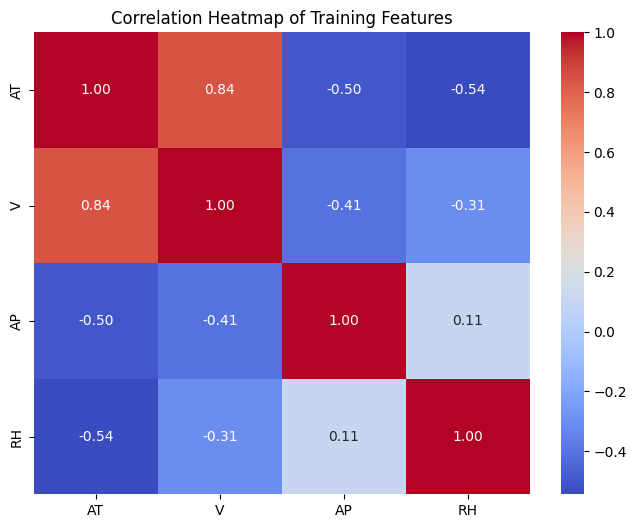

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

correlation_matrix = X_train_scaled_df.corr()

print("Correlation Matrix of Training Features:")
display(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Training Features')
plt.show()

# 3. Fitting an SVM with linear kernel and tuning hyperparameters

In [19]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import numpy as np

C_values = [0.01, 0.1, 1, 10, 100]
epsilon_values = [0.001, 0.01, 0.1, 0.5, 1.0]

best_mse = float('inf')
best_params = None
best_model = None

results = []

# Manual grid search
for c in C_values:
    for epsilon in epsilon_values:
        svr = SVR(kernel='linear', C=c, epsilon=epsilon)
        svr.fit(X_train_scaled, y_train)

        y_val_pred = svr.predict(X_val_scaled)
        mse = mean_squared_error(y_val, y_val_pred)

        results.append({
            'C': c,
            'epsilon': epsilon,
            'validation_mse': mse
        })

        if mse < best_mse:
            best_mse = mse
            best_params = {'C': c, 'epsilon': epsilon}
            best_model = svr

results_df = pd.DataFrame(results)
display(results_df)

print("\nBest hyperparameters:", best_params)
print("Best validation MSE:", best_mse)

,C,epsilon,validation_mse
0,0.01,0.001,23.204489
1,0.01,0.010,23.203696
2,0.01,0.100,23.223384
3,0.01,0.500,23.214676
4,0.01,1.000,23.270038
5,0.10,0.001,21.070918
6,0.10,0.010,21.074810
7,0.10,0.100,21.094324
8,0.10,0.500,21.128046
9,0.10,1.000,21.081506



Best hyperparameters: {'C': 0.1, 'epsilon': 0.001}
Best validation MSE: 21.0709182078558


# 4. Evaluation and scatter plot

In [20]:
from sklearn.metrics import r2_score
y_test_pred = best_model.predict(X_test_scaled)

mse_test = mean_squared_error(y_test, y_test_pred)

r2_test = r2_score(y_test, y_test_pred)

print(f"Performance of the best linear SVR model on the test set:")
print(f"Mean Squared Error (MSE): {mse_test:.4f}")
print(f"R-squared (R^2) Score: {r2_test:.4f}")

Performance of the best linear SVR model on the test set:
Mean Squared Error (MSE): 21.7905
R-squared (R^2) Score: 0.9244


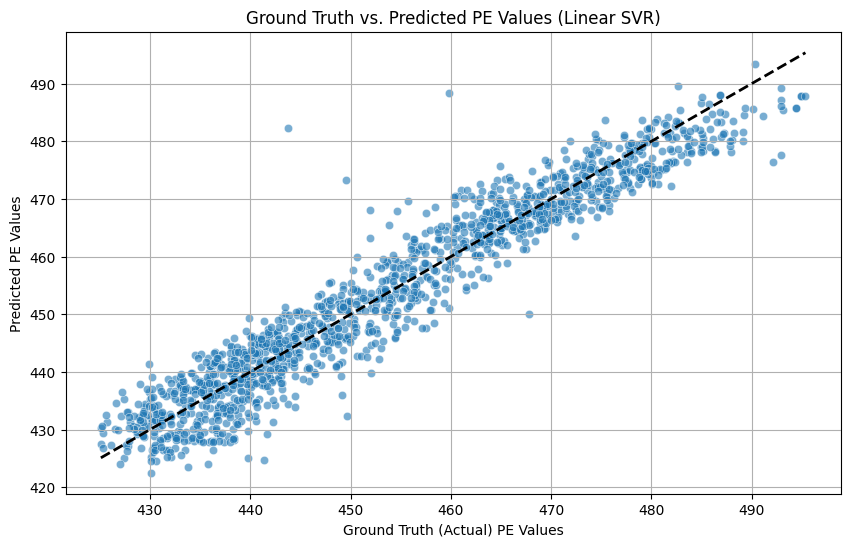

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.6)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)

plt.xlabel("Ground Truth (Actual) PE Values")
plt.ylabel("Predicted PE Values")
plt.title("Ground Truth vs. Predicted PE Values (Linear SVR)")
plt.grid(True)
plt.show()

# 5. SVM with RBF

In [16]:
from joblib import Parallel, delayed

C_values = [0.1, 1, 10, 100, 1000]
gamma_values = [0.001, 0.01, 0.1, 1, 10]
epsilon_values = [0.01, 0.1, 0.5, 1.0]

def train_and_evaluate_svr_rbf(c, gamma, epsilon, X_train_scaled, y_train, X_val_scaled, y_val):
    svr = SVR(kernel='rbf', C=c, gamma=gamma, epsilon=epsilon)
    svr.fit(X_train_scaled, y_train)
    y_val_pred = svr.predict(X_val_scaled)
    mse = mean_squared_error(y_val, y_val_pred)
    return {'C': c, 'gamma': gamma, 'epsilon': epsilon, 'validation_mse': mse, 'model': svr}

# Manual grid search with parallel processing
results = Parallel(n_jobs=-1)(delayed(train_and_evaluate_svr_rbf)(c, gamma, epsilon, X_train_scaled, y_train, X_val_scaled, y_val)
                               for c in C_values
                               for gamma in gamma_values
                               for epsilon in epsilon_values)

best_result = min(results, key=lambda x: x['validation_mse'])

best_params_rbf = {k: v for k, v in best_result.items() if k != 'model'}
best_model_rbf = best_result['model']
best_mse_rbf = best_result['validation_mse']

results_df_rbf = pd.DataFrame([{k: v for k, v in r.items() if k != 'model'} for r in results])
display(results_df_rbf)


print("\nBest hyperparameters (RBF kernel):", best_params_rbf)
print("Best validation MSE (RBF kernel):", best_mse_rbf)

,C,gamma,epsilon,validation_mse
0,0.1,0.001,0.01,226.158664
1,0.1,0.001,0.10,226.052107
2,0.1,0.001,0.50,226.310358
3,0.1,0.001,1.00,226.190515
4,0.1,0.010,0.01,44.033758
...,...,...,...,...
95,1000.0,1.000,1.00,13.476836
96,1000.0,10.000,0.01,32.333400
97,1000.0,10.000,0.10,31.580613
98,1000.0,10.000,0.50,28.613507



Best hyperparameters (RBF kernel): {'C': 100, 'gamma': 1, 'epsilon': 1.0, 'validation_mse': 13.36241377216982}
Best validation MSE (RBF kernel): 13.36241377216982


# 6. Evaluation and scatter plot

In [17]:
y_test_pred_rbf = best_model_rbf.predict(X_test_scaled)

mse_test_rbf = mean_squared_error(y_test, y_test_pred_rbf)

r2_test_rbf = r2_score(y_test, y_test_pred_rbf)

print(f"Performance of the best RBF SVR model on the test set:")
print(f"Mean Squared Error (MSE): {mse_test_rbf:.4f}")
print(f"R-squared (R^2) Score: {r2_test_rbf:.4f}")

Performance of the best RBF SVR model on the test set:
Mean Squared Error (MSE): 15.5849
R-squared (R^2) Score: 0.9459


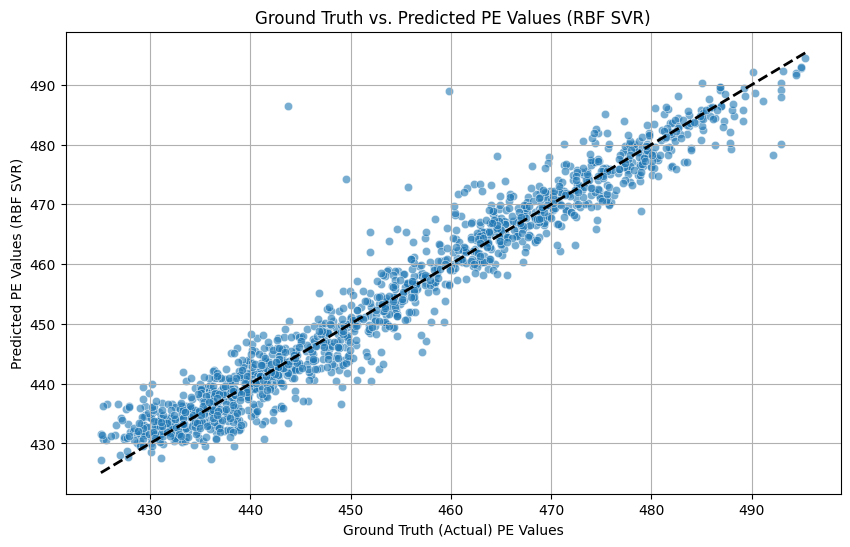

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred_rbf, alpha=0.6)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)

plt.xlabel("Ground Truth (Actual) PE Values")
plt.ylabel("Predicted PE Values (RBF SVR)")
plt.title("Ground Truth vs. Predicted PE Values (RBF SVR)")
plt.grid(True)
plt.show()